In [1]:
!pip install --upgrade keras tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.8 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolv

In [2]:
import os
import xml.etree.ElementTree as ET
from tqdm import tqdm

from matplotlib import pyplot as plt
import math

import numpy as np
from PIL import Image, ImageDraw

from keras.preprocessing.image import load_img, img_to_array
import tensorflow as tf

2025-04-14 11:07:09.199752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744628829.222089      19 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744628829.228863      19 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744628829.246863      19 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744628829.246886      19 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744628829.246889      19 computation_placer.cc:177] computation placer alr

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)  # Mengatur alokasi memori agar lebih fleksibel
        tf.config.set_visible_devices(gpus[0], 'GPU')  # Menetapkan GPU yang digunakan
        print("TensorFlow telah dikonfigurasi untuk menggunakan GPU.")
    except RuntimeError as e:
        print(e)
else:
    print("Tidak ada GPU yang terdeteksi. Pastikan driver dan TensorFlow versi GPU sudah terinstal.")

TensorFlow telah dikonfigurasi untuk menggunakan GPU.


In [4]:
print(tf.__version__)

2.19.0


In [5]:
def parse_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    boxes = []
    for obj in root.findall('object'):
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        boxes.append((xmin, ymin, xmax, ymax))

    return boxes

def load_dataset(image_dir, annotation_dir, target_size=(400, 200)):
    images = []
    boxes = []
    labels = []

    for filename in tqdm(os.listdir(image_dir), desc="Loading dataset"):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(image_dir, filename)

            # Load and resize image
            original_image = Image.open(image_path).convert("RGB")
            original_w, original_h = original_image.size
            resized_image = original_image.resize(target_size)
            image_array = img_to_array(resized_image) / 255.0

            # Parse bounding boxes
            xml_file = filename.rsplit('.', 1)[0] + '.xml'
            xml_path = os.path.join(annotation_dir, xml_file)
            box_list = parse_annotation(xml_path)

            scale_x = target_size[0] / original_w
            scale_y = target_size[1] / original_h

            for xmin, ymin, xmax, ymax in box_list:
                # Skala bounding box ke ukuran yang sudah di-resize
                xmin *= scale_x
                xmax *= scale_x
                ymin *= scale_y
                ymax *= scale_y

                # Normalisasi (untuk output regresi)
                x_center = (xmin + xmax) / 2 / target_size[0]
                y_center = (ymin + ymax) / 2 / target_size[1]
                width = (xmax - xmin) / target_size[0]
                height = (ymax - ymin) / target_size[1]

                images.append(image_array)        # gambar full
                boxes.append([x_center, y_center, width, height])  # satu bounding box per data
                labels.append(1)  # karena semua adalah plat

    return np.array(images), np.array(boxes), np.array(labels)

In [6]:
from pathlib import Path

img_dir = '/kaggle/input/plate-vehicle/images'
ann_dir = '/kaggle/input/plate-vehicle/Annotations'


img_dir = Path(img_dir)
ann_dir = Path(ann_dir)

images, boxes, labels = load_dataset(img_dir, ann_dir)

Loading dataset: 100%|██████████| 4006/4006 [07:20<00:00,  9.10it/s]


In [7]:
print(f"Images Shape: {images.shape}")
print(f"Boxes Shape: {boxes.shape}")
print(f"Labels Shape: {labels.shape}")

Images Shape: (5076, 200, 400, 3)
Boxes Shape: (5076, 4)
Labels Shape: (5076,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, box_train, box_test, label_train, label_test = train_test_split(
    images, boxes, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels 
)

In [9]:
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Train Shape: (4060, 200, 400, 3)
Test Shape: (1016, 200, 400, 3)


In [10]:
def display_sample_images(images, boxes=None, labels=None, num_images=6):
    cols = 3
    rows = math.ceil(num_images / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten()

    for i in range(num_images):
        image = images[i]
        if image.max() <= 1.0:
            image = (image * 255).astype('uint8')

        img_h, img_w = image.shape[0], image.shape[1]

        # Konversi ke [xmin, ymin, xmax, ymax] kalau ada bounding box-nya
        if boxes is not None:
            box = boxes[i]
            x_center, y_center, width, height = box
            xmin = int((x_center - width / 2) * img_w)
            xmax = int((x_center + width / 2) * img_w)
            ymin = int((y_center - height / 2) * img_h)
            ymax = int((y_center + height / 2) * img_h)
            image_pil = Image.fromarray(image)
            draw = ImageDraw.Draw(image_pil)
            draw.rectangle([xmin, ymin, xmax, ymax], outline='red', width=2)
            image = np.array(image_pil)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(f"Image {i+1}")

    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

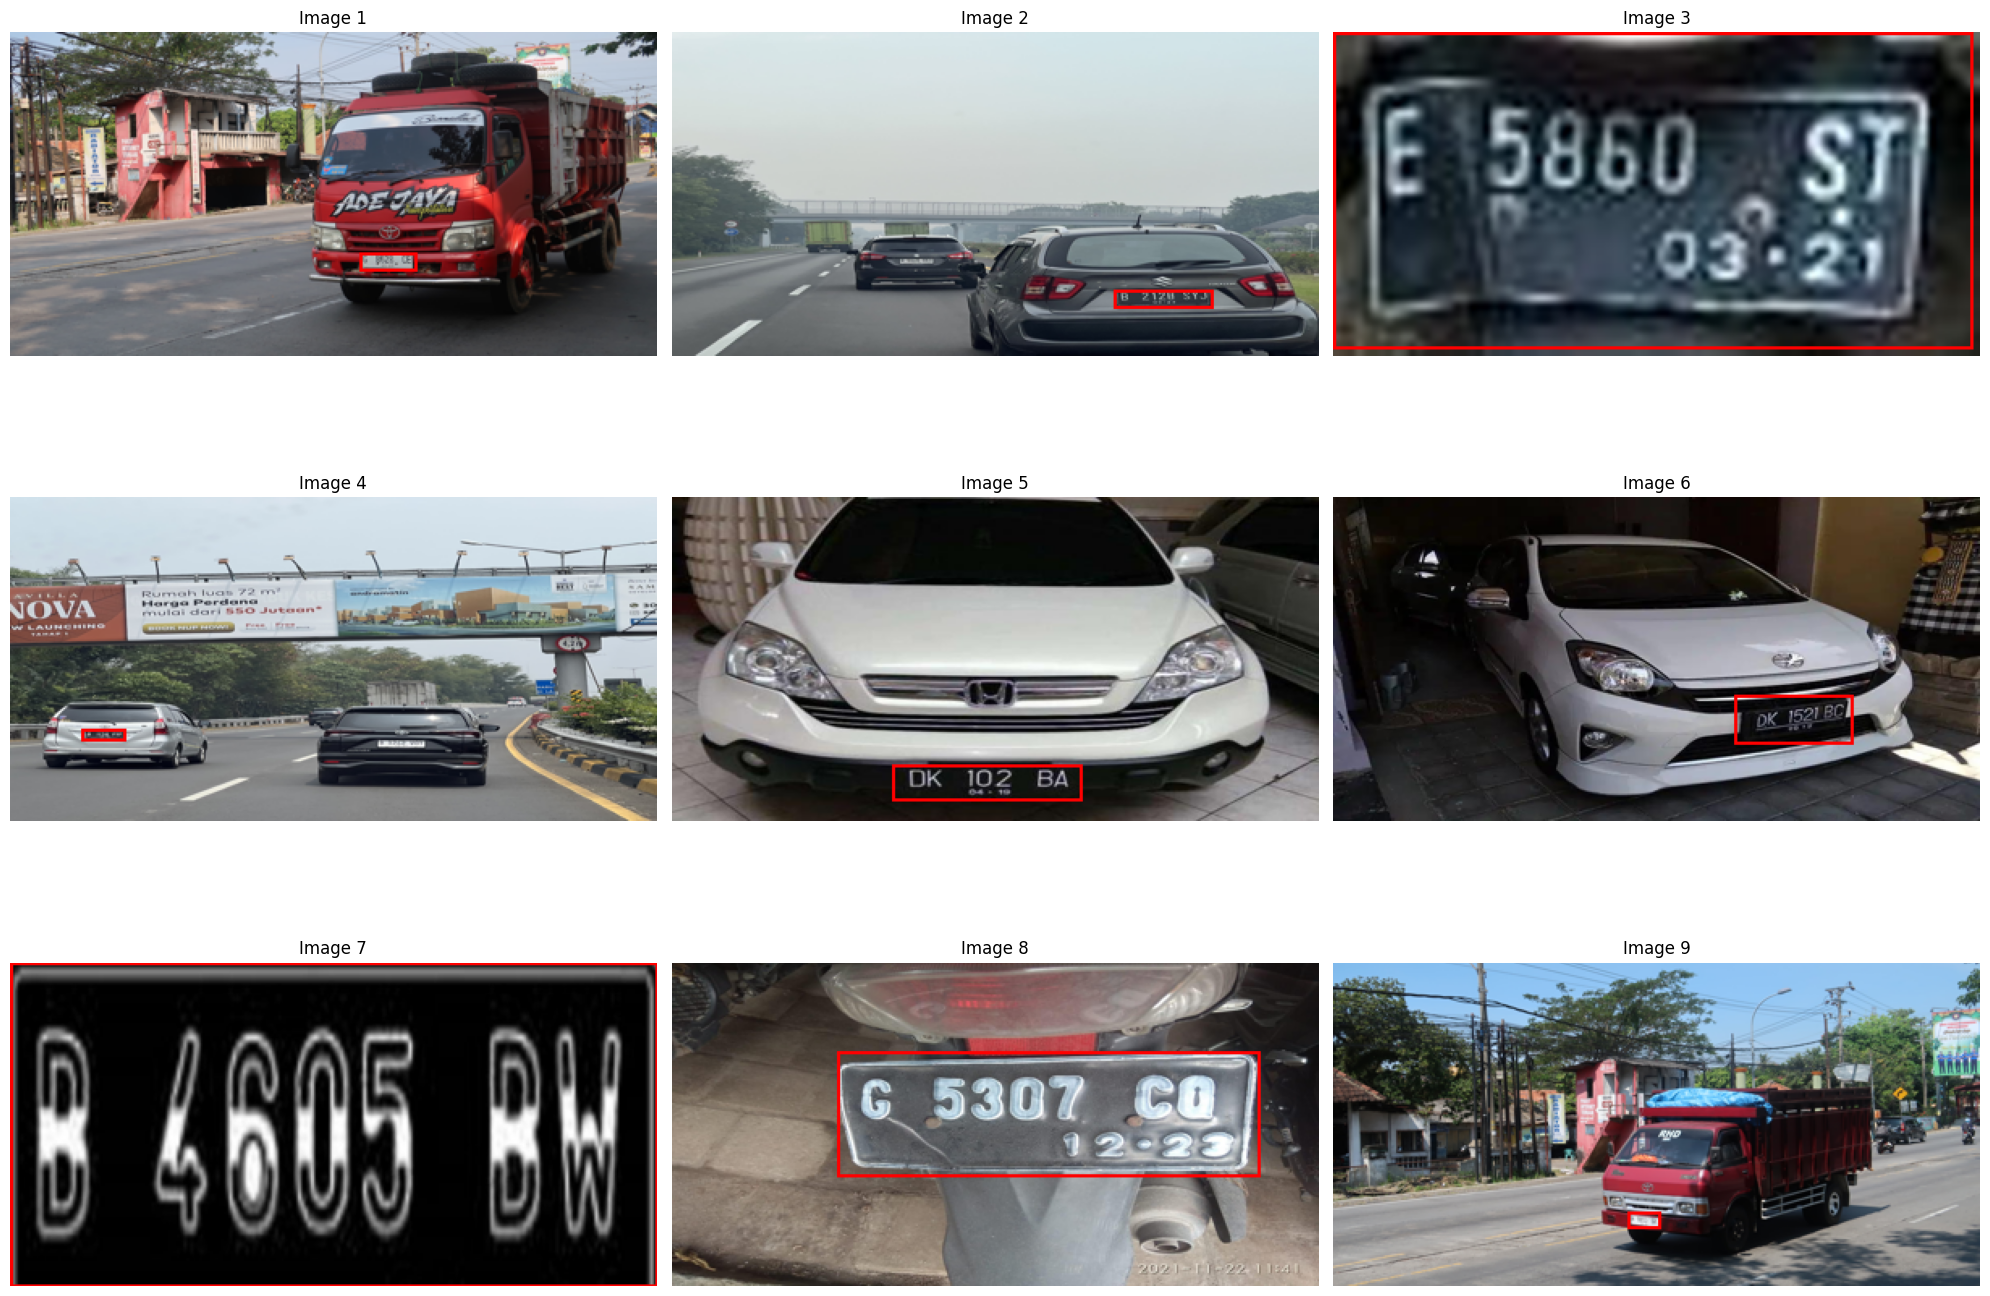

In [11]:
display_sample_images(X_train, box_train, label_train, num_images=9)

In [12]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def create_model(input_shape):
    inputs = Input(shape=input_shape)

    # Feature extractor
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    # Shared Dense layer
    shared = Dense(256, activation='relu')(x)
    shared = Dropout(0.3)(shared)

    # Output: classification (biner)
    class_output = Dense(1, activation='sigmoid', name='class_output')(shared)

    # Output: bounding box (normalized)
    bbox_output = Dense(4, activation='sigmoid', name='bbox_output')(shared)

    model = Model(inputs=inputs, outputs=[class_output, bbox_output])

    model.compile(
        optimizer='adam',
        loss={'bbox_output': 'mse', 'class_output': 'binary_crossentropy'},
        metrics={'bbox_output': ['mae'], 'class_output': ['accuracy']}
    )

    return model

In [13]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Setup callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

In [14]:
# Create the model
model = create_model(input_shape=(200, 400, 3))

model.summary()

I0000 00:00:1744629285.726638      19 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 200, 400, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 200, 400, 32)   │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 200, 400, 32)   │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 100, 200, 32)   │              0 │ batch_normalization[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 100, 200, 64)   │         18,496 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 100, 200, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 50, 100, 64)    │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 50, 100, 128)   │         73,856 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 50, 100, 128)   │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 25, 50, 128)    │              0 │ batch_normalization_2… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 25, 50, 256)    │        295,168 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 25, 50, 256)    │          1,024 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 12, 25, 256)    │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 76800)          │              0 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 512)            │     39,322,112 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)    

 Total params: 39,845,061 (152.00 MB)

 Trainable params: 39,844,101 (151.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
history = model.fit(
    X_train, 
    {'bbox_output': box_train, 'class_output': label_train},
    validation_data=(X_test, {'bbox_output': box_test, 'class_output': label_test}),
    epochs=100,
    batch_size=32,
    # callbacks=callbacks
)

Epoch 1/100


I0000 00:00:1744629305.513918      72 service.cc:152] XLA service 0x7bcd94019600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744629305.513974      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1744629306.235738      72 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/127 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - bbox_output_loss: 0.3099 - bbox_output_mae: 0.4700 - class_output_accuracy: 0.7422 - class_output_loss: 0.4606 - loss: 0.7706  

I0000 00:00:1744629314.219770      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


127/127 ━━━━━━━━━━━━━━━━━━━━ 37s 183ms/step - bbox_output_loss: 0.3126 - bbox_output_mae: 0.4634 - class_output_accuracy: 0.9854 - class_output_loss: 0.0261 - loss: 0.3387 - val_bbox_output_loss: 0.3376 - val_bbox_output_mae: 0.4899 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 0.0000e+00 - val_loss: 0.3375
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - bbox_output_loss: 0.2158 - bbox_output_mae: 0.3653 - class_output_accuracy: 1.0000 - class_output_loss: 0.0000e+00 - loss: 0.2158 - val_bbox_output_loss: 0.2193 - val_bbox_output_mae: 0.3710 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 0.0000e+00 - val_loss: 0.2193
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - bbox_output_loss: 0.1984 - bbox_output_mae: 0.3481 - class_output_accuracy: 1.0000 - class_output_loss: 0.0000e+00 - loss: 0.1984 - val_bbox_output_loss: 0.2057 - val_bbox_output_mae: 0.3575 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 0.0000e+00 - val_loss: 0.205

In [16]:
def plot_training_history(history):
    plt.figure(figsize=(18, 10))

    # 1. Accuracy klasifikasi
    plt.subplot(2, 2, 1)
    plt.plot(history.history['class_output_accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_class_output_accuracy'], label='Val Accuracy')
    plt.title('Classification Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # 2. Loss total
    plt.subplot(2, 2, 2)
    plt.plot(history.history['loss'], label='Train Total Loss')
    plt.plot(history.history['val_loss'], label='Val Total Loss')
    plt.title('Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # 3. MAE bounding box (regresi)
    plt.subplot(2, 2, 3)
    plt.plot(history.history['bbox_output_mae'], label='Train MAE')
    plt.plot(history.history['val_bbox_output_mae'], label='Val MAE')
    plt.title('Bounding Box MAE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()

    # 4. Bounding box loss (regresi)
    plt.subplot(2, 2, 4)
    plt.plot(history.history['bbox_output_loss'], label='Train BBox Loss')
    plt.plot(history.history['val_bbox_output_loss'], label='Val BBox Loss')
    plt.title('Bounding Box Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

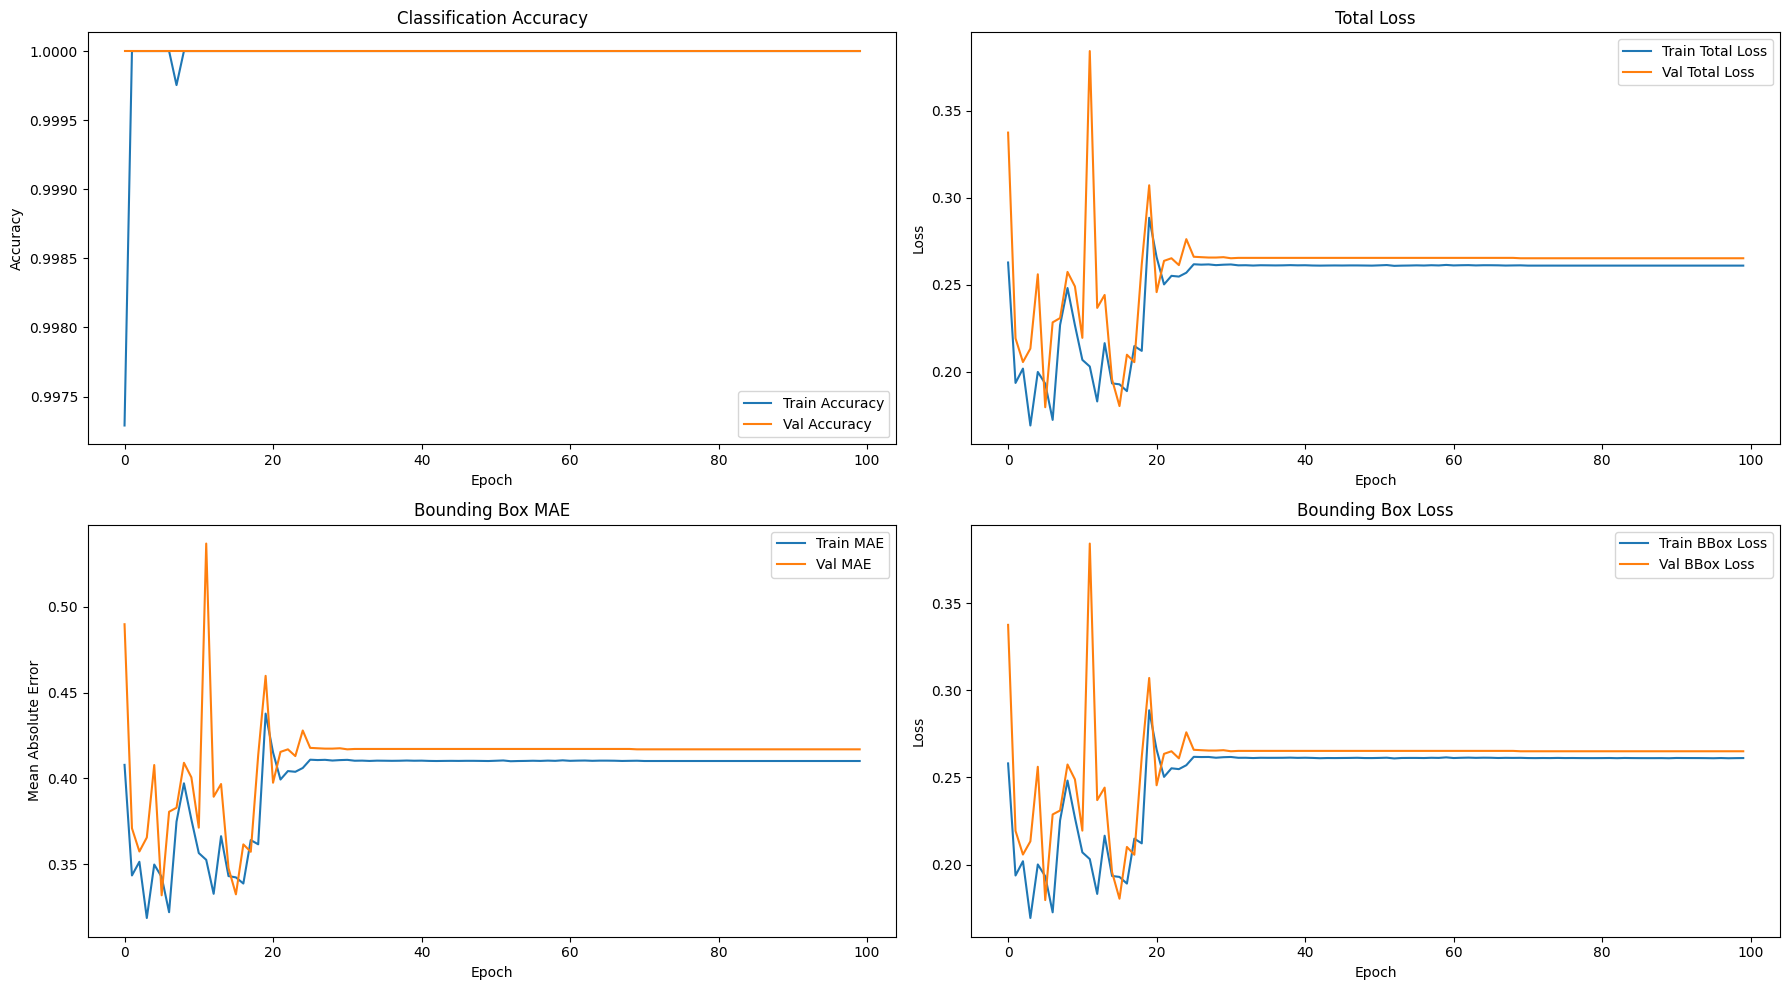

In [17]:
plot_training_history(history)